# 迴歸進階 (Advanced Regression)

學習目標：
- 了解多變數迴歸
- 學會 Ridge 和 Lasso 正規化
- 知道過擬合是什麼以及如何避免

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 1. 多變數迴歸

上次用「訓練時數」預測成績（1個特徵）。
現在用多個特徵同時預測：
- 訓練時數
- 睡眠時數
- 年齡
- 過去比賽次數

In [2]:
# 建立模擬資料（4個特徵）
np.random.seed(42)
n = 200

training_hours = np.random.uniform(5, 30, n)
sleep_hours    = np.random.uniform(5, 9, n)
age            = np.random.uniform(18, 35, n)
competitions   = np.random.randint(1, 50, n)

# 成績由這些特徵決定（加入一些雜訊）
performance = (1.5 * training_hours +
               3.0 * sleep_hours +
              -0.5 * age +
               0.3 * competitions +
               np.random.normal(0, 5, n) + 40)

X = np.column_stack([training_hours, sleep_hours,
                     age, competitions])
y = performance

feature_names = ['訓練時數', '睡眠時數', '年齡', '比賽次數']
print(f'資料形狀：{X.shape}')
print(f'成績範圍：{y.min():.1f} ~ {y.max():.1f}')

資料形狀：(200, 4)
成績範圍：46.9 ~ 110.4


In [3]:
# 標準化 + 切分資料
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# 普通線性迴歸
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('線性迴歸結果：')
print(f'R² = {r2_score(y_test, y_pred):.3f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')
print('\n各特徵係數：')
for name, coef in zip(feature_names, lr.coef_):
    print(f'  {name}: {coef:.3f}')

線性迴歸結果：
R² = 0.747
RMSE = 5.633

各特徵係數：
  訓練時數: 10.580
  睡眠時數: 3.938
  年齡: -3.228
  比賽次數: 4.193


## 2. 過擬合問題

模型太複雜時，會「死記」訓練資料，
對新資料預測很差，這叫過擬合（Overfitting）。

解決方法：正規化（Regularization）
- Ridge：對所有係數加懲罰，讓係數變小
- Lasso：讓不重要的特徵係數直接變成0

In [4]:
# Ridge 迴歸
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso 迴歸
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print('三種模型比較：')
print(f'{"模型":<10} {"R²":>8} {"RMSE":>8}')
print('-' * 28)
for name, pred in [('Linear', y_pred),
                   ('Ridge',  y_pred_ridge),
                   ('Lasso',  y_pred_lasso)]:
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f'{name:<10} {r2:>8.3f} {rmse:>8.3f}')

三種模型比較：
模型               R²     RMSE
----------------------------
Linear        0.747    5.633
Ridge         0.749    5.608
Lasso         0.752    5.579


/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 30496 (\N{CJK UNIFIED IDEOGRAPH-7720}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36867/42915729.py:16: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missi

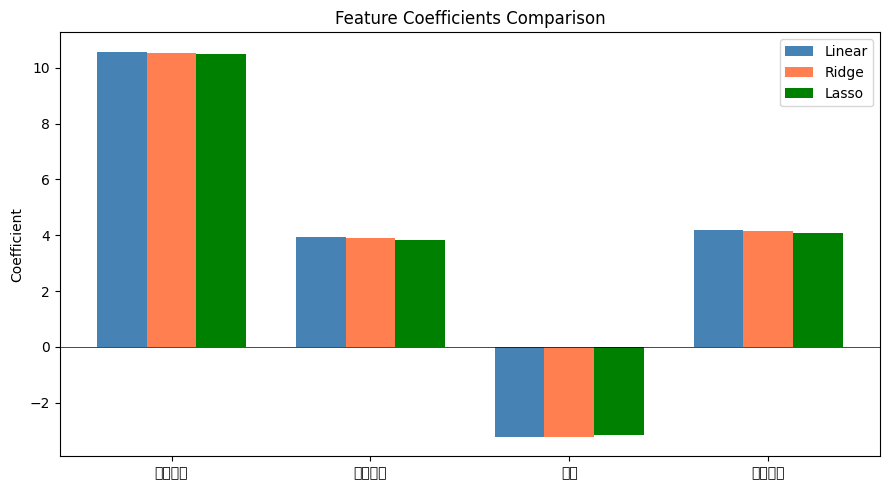

In [5]:
# 視覺化：三種模型的係數比較
x = np.arange(len(feature_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, lr.coef_,    width, label='Linear', color='steelblue')
ax.bar(x,         ridge.coef_, width, label='Ridge',  color='coral')
ax.bar(x + width, lasso.coef_, width, label='Lasso',  color='green')

ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.set_ylabel('Coefficient')
ax.set_title('Feature Coefficients Comparison')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## 3. 我的學習筆記

1. 這個主題在做什麼：
   用多個特徵同時預測目標，
   並用正規化避免模型過擬合。

2. 三種迴歸一句話總結：
   - Linear：基礎，沒有懲罰
   - Ridge：所有特徵都保留，但係數變小
   - Lasso：不重要的特徵係數直接歸零（自動選特徵）

3. 我覺得最難理解的地方：
   程序不熟練

4. 這個跟我研究的連結：
   預測運動員表現時特徵很多，
   Lasso 可以自動篩選出真正重要的指標，
   這在運動科學研究中非常實用。